In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import MinMaxScaler

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D3 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical using the min max scaling
scaler = MinMaxScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

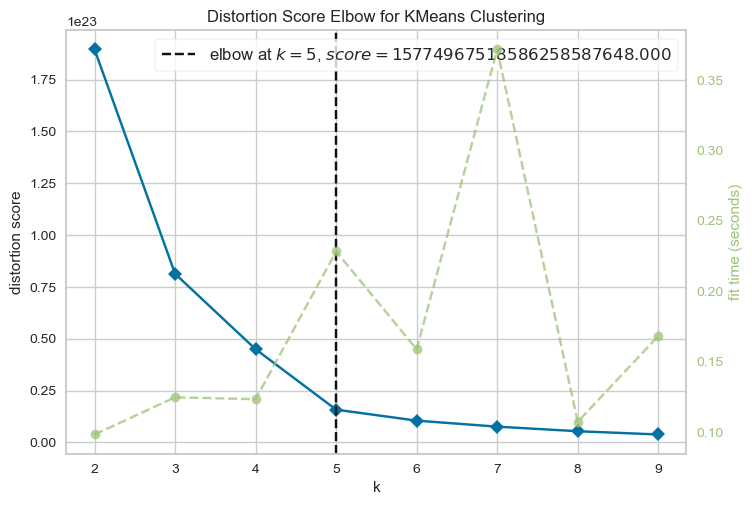

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: glrlm_GrayLevelVariance_CT_b20, Coefficient: 14.784139674627836


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: glcm_Id_d_1_PET_b2, Coefficient: -16.873675067491916


...

Cluster 2: Most important feature: gldm_HighGrayLevelEmphasis_d_1_PET_c04, Coefficient: -10.110801272256838


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: glszm_LargeAreaEmphasis_PET_b2, Coefficient: -41.459819680000855


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: glcm_DifferenceEntropy_d_1_PET_c04, Coefficient: -10.104929153660365


In [21]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [22]:
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [23]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [24]:
X_new

,glrlm_GrayLevelVariance_CT_b20,glcm_Id_d_1_PET_b2,gldm_HighGrayLevelEmphasis_d_1_PET_c04,glszm_LargeAreaEmphasis_PET_b2,glcm_DifferenceEntropy_d_1_PET_c04
0,22.310788,0.826905,18.049772,2.221606e+06,0.947107
1,20.557318,0.902339,13.666085,3.302109e+05,1.069703
2,21.092104,0.917698,17.943254,1.199973e+07,0.913659
3,22.786001,0.936960,12.743182,1.827427e+06,1.016896
4,29.182742,0.899247,21.016341,6.505360e+05,1.121354
...,...,...,...,...,...
134,4.906583,0.862760,14.866002,1.974993e+06,1.040340
135,16.015030,0.931700,24.299374,2.688230e+07,0.907673
136,24.706900,0.829673,14.135753,1.251201e+06,0.993644
137,5.157909,0.916060,23.651545,7.599865e+06,0.993376


In [25]:
X_new_std

,glrlm_GrayLevelVariance_CT_b20,glcm_Id_d_1_PET_b2,gldm_HighGrayLevelEmphasis_d_1_PET_c04,glszm_LargeAreaEmphasis_PET_b2,glcm_DifferenceEntropy_d_1_PET_c04
0,0.072353,0.473776,0.503938,0.004304,0.482145
1,0.066055,0.737560,0.312209,0.000548,0.637240
2,0.067975,0.791268,0.499279,0.023720,0.439830
3,0.074060,0.858627,0.271845,0.003521,0.570434
4,0.097036,0.726747,0.633687,0.001184,0.702582
...,...,...,...,...,...
134,0.009840,0.599157,0.364690,0.003814,0.600093
135,0.049739,0.840233,0.777276,0.053273,0.432258
136,0.080959,0.483455,0.332751,0.002377,0.541018
137,0.010743,0.785541,0.748942,0.014984,0.540680


In [26]:
MAASTRO_new

,glrlm_GrayLevelVariance_CT_b20,glcm_Id_d_1_PET_b2,gldm_HighGrayLevelEmphasis_d_1_PET_c04,glszm_LargeAreaEmphasis_PET_b2,glcm_DifferenceEntropy_d_1_PET_c04
0,14.212485,0.833510,21.626184,4.625182e+06,0.925732
1,54.975356,0.899231,8.555308,7.216348e+06,0.869771
2,27.032891,0.849754,13.424721,2.600670e+06,0.891144
3,146.781623,0.897983,11.513187,3.469465e+06,0.894215
4,9.468732,0.911954,16.450337,1.657330e+07,0.876239
...,...,...,...,...,...
94,40.637943,0.688625,16.219044,2.386110e+05,0.931759
95,143.812625,0.867573,12.065606,4.294238e+06,0.908061
96,22.317077,0.924211,11.931657,4.200270e+07,0.834597
97,20.533289,0.854212,15.393730,4.154040e+06,0.879573


In [27]:
MAASTRO_new_std

,glrlm_GrayLevelVariance_CT_b20,glcm_Id_d_1_PET_b2,gldm_HighGrayLevelEmphasis_d_1_PET_c04,glszm_LargeAreaEmphasis_PET_b2,glcm_DifferenceEntropy_d_1_PET_c04
0,0.043265,0.496872,0.660359,0.009077,0.455103
1,0.189678,0.726691,0.088680,0.014222,0.384308
2,0.089314,0.553678,0.301653,0.005057,0.411347
3,0.519430,0.722327,0.218049,0.006782,0.415232
4,0.026226,0.771182,0.433984,0.032802,0.392491
...,...,...,...,...,...
94,0.138181,-0.009776,0.423868,0.000366,0.462729
95,0.508766,0.615989,0.242210,0.008420,0.432748
96,0.072375,0.814045,0.236351,0.083298,0.339811
97,0.065968,0.569265,0.387771,0.008141,0.396709


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [28]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 09:36:43,634] A new study created in memory with name: no-name-d38cb761-0517-4581-87ee-33a964c06f13
python(9718) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 09:36:44,028] A new study created in memory with name: no-name-11e161de-2a65-47dc-a704-939888cae238


Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.5077519379844961
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.5703422053231939
Fold 5 C-index: 0.5236051502145923
[I 2024-04-16 09:36:44,022] Trial 0 finished with value: 0.5720106224579531 and parameters: {}. Best is trial 0 with value: 0.5720106224579531.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5720106224579531], datetime_start=datetime.datetime(2024, 4, 16, 9, 36, 43, 823044), datetime_complete=datetime.datetime(2024, 4, 16, 9, 36, 44, 21053), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5720106224579531


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26909147090655516
Fold 2 IBS: 0.24791583349354804
Fold 3 IBS: 0.1892456748633832
Fold 4 IBS: 0.26903197753316455
Fold 5 IBS: 0.24213621685175502
[I 2024-04-16 09:36:44,305] Trial 0 finished with value: 0.2434842347296812 and parameters: {}. Best is trial 0 with value: 0.2434842347296812.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2434842347296812], datetime_start=datetime.datetime(2024, 4, 16, 9, 36, 44, 60795), datetime_complete=datetime.datetime(2024, 4, 16, 9, 36, 44, 305510), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2434842347296812


In [29]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [30]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.572
train_ibs:  0.243


#### Test

In [31]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [32]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.538
IBS score: 0.241


In [33]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [34]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [35]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:36:44,586] A new study created in memory with name: no-name-c68e5f19-5b14-4d67-bfb9-3421afe1e648


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 09:36:44,945] A new study created in memory with name: no-name-1b854aa0-ca48-4f33-ae71-45dc215f96a9


Fold 1 C-index: 0.5318725099601593
Fold 2 C-index: 0.4844961240310077
Fold 3 C-index: 0.6
Fold 4 C-index: 0.5532319391634981
Fold 5 C-index: 0.5515021459227468
[I 2024-04-16 09:36:44,941] Trial 0 finished with value: 0.5442205438154823 and parameters: {}. Best is trial 0 with value: 0.5442205438154823.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5442205438154823], datetime_start=datetime.datetime(2024, 4, 16, 9, 36, 44, 738347), datetime_complete=datetime.datetime(2024, 4, 16, 9, 36, 44, 941512), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5442205438154823


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724710029491034
Fold 2 IBS: 0.23203988483920637
Fold 3 IBS: 0.2289818672409479
Fold 4 IBS: 0.24197477166711975
Fold 5 IBS: 0.22939559282013616
[I 2024-04-16 09:36:45,117] Trial 0 finished with value: 0.23592784337246414 and parameters: {}. Best is trial 0 with value: 0.23592784337246414.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784337246414], datetime_start=datetime.datetime(2024, 4, 16, 9, 36, 44, 990058), datetime_complete=datetime.datetime(2024, 4, 16, 9, 36, 45, 117774), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784337246414


In [36]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [37]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.544
train_ibs:  0.236


#### Test

In [38]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [39]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.504


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [40]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [41]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:36:45,335] A new study created in memory with name: no-name-cff8856d-21ce-4f8a-9cb2-df2a4e1b9653


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5179282868525896


[I 2024-04-16 09:36:45,619] A new study created in memory with name: no-name-ec10e820-ef77-4ba5-afb0-f4b4d1691bcc


Fold 2 C-index: 0.5077519379844961
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.5278969957081545
[I 2024-04-16 09:36:45,612] Trial 0 finished with value: 0.5549060435751108 and parameters: {}. Best is trial 0 with value: 0.5549060435751108.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5549060435751108], datetime_start=datetime.datetime(2024, 4, 16, 9, 36, 45, 401434), datetime_complete=datetime.datetime(2024, 4, 16, 9, 36, 45, 612601), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5549060435751108


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2683316149248544
Fold 2 IBS: 0.2477548014078629
Fold 3 IBS: 0.22210950124491913
Fold 4 IBS: 0.2686089034622538
Fold 5 IBS: 0.24166405309597214
[I 2024-04-16 09:36:45,965] Trial 0 finished with value: 0.2496937748271725 and parameters: {}. Best is trial 0 with value: 0.2496937748271725.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.2496937748271725], datetime_start=datetime.datetime(2024, 4, 16, 9, 36, 45, 677136), datetime_complete=datetime.datetime(2024, 4, 16, 9, 36, 45, 965281), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.2496937748271725


In [42]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [43]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.555
train_ibs:  0.25


#### Test

In [44]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [45]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.536


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.242


In [46]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [47]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:36:46,348] A new study created in memory with name: no-name-0f216b03-36a7-4151-9f60-7f819796143b


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.49612403100775193
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5513307984790875
Fold 5 C-index: 0.5236051502145923
[I 2024-04-16 09:36:46,609] Trial 0 finished with value: 0.5479561681874678 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5479561681874678.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.49612403100775193
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5665399239543726
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 09:36:46,707] Trial 1 finished with value: 0.5586617588212285 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.5586617588212285.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.49612403100775193
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 09:36:46,807] Trial 2 finished with value: 0.5601826713687569 and parameters: {'l1_ratio': 0.2269287684188466

Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.49612403100775193
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 09:36:49,862] Trial 26 finished with value: 0.5601826713687569 and parameters: {'l1_ratio': 0.23521758130887002}. Best is trial 11 with value: 0.5647454090113424.
Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.5077519379844961
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5741444866920152
Fold 5 C-index: 0.5278969957081545
[I 2024-04-16 09:36:50,067] Trial 27 finished with value: 0.5549060435751108 and parameters: {'l1_ratio': 0.8345729974660353}. Best is trial 11 with value: 0.5647454090113424.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.49612403100775193
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 09:36:50,197] Trial 28 finished with value: 0.5617035839162854 and parameters: {'l1_ratio': 0.050326165414

Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 09:36:52,536] Trial 50 finished with value: 0.5609431276425212 and parameters: {'l1_ratio': 0.18159364780042775}. Best is trial 11 with value: 0.5647454090113424.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.49612403100775193
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 09:36:52,625] Trial 51 finished with value: 0.5647454090113424 and parameters: {'l1_ratio': 0.031397063667398056}. Best is trial 11 with value: 0.5647454090113424.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-index: 0.49612403100775193
Fold 3 C-index: 0.6468085106382979
Fold 4 C-index: 0.5855513307984791
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 09:36:52,752] Trial 52 finished with value: 0.5624640401900496 and parameters: {'l1_ratio': 0.08323094124173218}. Best is trial 11 with value: 0.5647454090113424.
Fold 1 C-index: 0.5258964143426295
Fold 2 C-ind

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.26812269094655006
Fold 2 IBS: 0.2347055124165144
Fold 3 IBS: 0.2239306715753545
Fold 4 IBS: 0.24604452412818154
Fold 5 IBS: 0.24155023104075318
[I 2024-04-16 09:36:58,596] Trial 0 finished with value: 0.24287072602147072 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24287072602147072.
Fold 1 IBS: 0.2469446107365109
Fold 2 IBS: 0.2329915024883719
Fold 3 IBS: 0.22674062911543377
Fold 4 IBS: 0.24306522017218252
Fold 5 IBS: 0.22883679689139283
[I 2024-04-16 09:36:58,745] Trial 1 finished with value: 0.23571575188077837 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.23571575188077837.
Fold 1 IBS: 0.2469843997090731
Fold 2 IBS: 0.23277921749098782
Fold 3 IBS: 0.22718425178231408
Fold 4 IBS: 0.24275547588427276
Fold 5 IBS: 0.22893719409697202
[I 2024-04-16 09:36:58,888] Trial 2 finished with value: 0.23572810779272393 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 1 with value: 0.23571575188077

Fold 1 IBS: 0.24692714647668476
Fold 2 IBS: 0.23312120187278426
Fold 3 IBS: 0.2264825946279604
Fold 4 IBS: 0.24327074228973194
Fold 5 IBS: 0.22878105330606316
[I 2024-04-16 09:37:02,842] Trial 25 finished with value: 0.23571654771464493 and parameters: {'l1_ratio': 0.3213310297120281}. Best is trial 1 with value: 0.23571575188077837.
Fold 1 IBS: 0.24690358504528317
Fold 2 IBS: 0.2335696702129014
Fold 3 IBS: 0.22565724568318138
Fold 4 IBS: 0.2440711168593898
Fold 5 IBS: 0.22861677414872478
[I 2024-04-16 09:37:02,996] Trial 26 finished with value: 0.23576367838989612 and parameters: {'l1_ratio': 0.43696099753129897}. Best is trial 1 with value: 0.23571575188077837.
Fold 1 IBS: 0.2470398090694434
Fold 2 IBS: 0.23256424644400317
Fold 3 IBS: 0.22766318104210526
Fold 4 IBS: 0.2424777516636464
Fold 5 IBS: 0.22905167305716984
[I 2024-04-16 09:37:03,129] Trial 27 finished with value: 0.23575933225527362 and parameters: {'l1_ratio': 0.16443773096599684}. Best is trial 1 with value: 0.23571575188

Fold 1 IBS: 0.246907322755145
Fold 2 IBS: 0.23371399928259468
Fold 3 IBS: 0.22541135874182747
Fold 4 IBS: 0.24435707396120931
Fold 5 IBS: 0.22857216454486817
[I 2024-04-16 09:37:06,475] Trial 50 finished with value: 0.23579238385712892 and parameters: {'l1_ratio': 0.47241766561900594}. Best is trial 41 with value: 0.2357153289934117.
Fold 1 IBS: 0.24693583597102903
Fold 2 IBS: 0.23305201349596544
Fold 3 IBS: 0.2266190720470841
Fold 4 IBS: 0.24315958507636753
Fold 5 IBS: 0.22881028698102884
[I 2024-04-16 09:37:06,609] Trial 51 finished with value: 0.235715358714295 and parameters: {'l1_ratio': 0.3026960346421114}. Best is trial 41 with value: 0.2357153289934117.
Fold 1 IBS: 0.24693296959562178
Fold 2 IBS: 0.23307362157054773
Fold 3 IBS: 0.22657616528335367
Fold 4 IBS: 0.24319393410499202
Fold 5 IBS: 0.2288010353860096
[I 2024-04-16 09:37:06,801] Trial 52 finished with value: 0.23571554518810495 and parameters: {'l1_ratio': 0.308540184132424}. Best is trial 41 with value: 0.2357153289934

Fold 5 IBS: 0.22871297197157103
[I 2024-04-16 09:37:09,687] Trial 74 finished with value: 0.23572679912136577 and parameters: {'l1_ratio': 0.36679466960093865}. Best is trial 61 with value: 0.23571532829995728.
Fold 1 IBS: 0.24694498865417688
Fold 2 IBS: 0.23298905757063262
Fold 3 IBS: 0.22674558459820607
Fold 4 IBS: 0.2430614614548309
Fold 5 IBS: 0.22883788693610216
[I 2024-04-16 09:37:09,790] Trial 75 finished with value: 0.2357157958427897 and parameters: {'l1_ratio': 0.2855408992866636}. Best is trial 61 with value: 0.23571532829995728.
Fold 1 IBS: 0.24690357270723365
Fold 2 IBS: 0.2335679988368003
Fold 3 IBS: 0.2256601456943417
Fold 4 IBS: 0.24406788473889804
Fold 5 IBS: 0.22861731243512437
[I 2024-04-16 09:37:09,910] Trial 76 finished with value: 0.2357633828824796 and parameters: {'l1_ratio': 0.43654564723936473}. Best is trial 61 with value: 0.23571532829995728.
Fold 1 IBS: 0.2469826167100253
Fold 2 IBS: 0.2327873165033172
Fold 3 IBS: 0.227166813515101
Fold 4 IBS: 0.24276666312

In [48]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [49]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.565
train_ibs:  0.236


#### Test

In [50]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [51]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.012263077917218868)

test_cindex : 0.518


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.2990583608019828)

test_ibs:  0.229


In [52]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [53]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 09:37:13,994] A new study created in memory with name: no-name-c599cf34-5e4b-4976-993e-64328cc31132


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.562015503875969
Fold 3 C-index: 0.6297872340425532
Fold 4 C-index: 0.6311787072243346
Fold 5 C-index: 0.5429184549356223
[I 2024-04-16 09:37:17,124] Trial 0 finished with value: 0.561626195155138 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.561626195155138.
Fold 1 C-index: 0.4262948207171315
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.5404255319148936
Fold 4 C-index: 0.49429657794676807
Fold 5 C-index: 0.5278969957081545
[I 2024-04-16 09:37:19,325] Trial 1 finished with value: 0.5140618550248315 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, '

Fold 5 C-index: 0.5300429184549357
[I 2024-04-16 09:37:42,541] Trial 15 finished with value: 0.587210957103814 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 7, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 383, 'oob_score': False, 'max_samples': 0.4747428535255964, 'max_features': None, 'min_weight_fraction_leaf': 0.22876430419908877, 'warm_start': False}. Best is trial 15 with value: 0.587210957103814.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:37:45,383] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 7, 'min_samples_leaf': 19, 'max_depth': 1, 'n_estimators': 388, 'oob_score': False, 'max_samples': 0.44827686549014745, 'max_features': None, 'min_weight_fraction_leaf': 0.39634100763828095, 'warm_start': False}. Best is trial 15 with value: 0.587210957103814.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5

Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6115879828326181
[I 2024-04-16 09:38:10,229] Trial 30 finished with value: 0.6520689355356654 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 8, 'min_samples_leaf': 18, 'max_depth': 5, 'n_estimators': 469, 'oob_score': True, 'max_samples': 0.5031474498124319, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.20001380215328324, 'warm_start': True}. Best is trial 18 with value: 0.6572845716693143.
Fold 1 C-index: 0.4302788844621514
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.6844106463878327
Fold 5 C-index: 0.630901287553648
[I 2024-04-16 09:38:11,609] Trial 31 finished with value: 0.6467991796794069 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 8, 'min_samples_leaf': 14, 'max_depth': 5, 'n_estimators': 327, 'oob_score': True, 'max_samples': 0.5765850253940433, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.08337942017117347, 'warm_start': True}. Best is tri

...

Fold 1 IBS: 0.26181491388751366
Fold 2 IBS: 0.22740578431008052
Fold 3 IBS: 0.22271654957229198
Fold 4 IBS: 0.23920720446913243
Fold 5 IBS: 0.24018980107504806
[I 2024-04-16 09:41:26,441] Trial 32 finished with value: 0.23826685066281333 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 7, 'min_samples_leaf': 11, 'max_depth': 11, 'n_estimators': 422, 'oob_score': False, 'max_samples': 0.6329701743590335, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.17047196706970782}. Best is trial 17 with value: 0.2320709155931624.
Fold 1 IBS: 0.25347322139140854
Fold 2 IBS: 0.22254093561224872
Fold 3 IBS: 0.21887990333527155
Fold 4 IBS: 0.2341068067095657
Fold 5 IBS: 0.2341371166240916
[I 2024-04-16 09:41:31,435] Trial 33 finished with value: 0.23262759673451722 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 9, 'min_samples_leaf': 8, 'max_depth': 8, 'n_estimators': 389, 'oob_score': False, 'max_samples': 0.5110866777849374, 'max_features': 'sqrt', 'min_weight_fraction_

Fold 1 IBS: 0.25390463810247477
Fold 2 IBS: 0.2237677492562935
Fold 3 IBS: 0.2208976780527287
Fold 4 IBS: 0.23667877435477952
Fold 5 IBS: 0.23601282853233285
[I 2024-04-16 09:42:25,342] Trial 48 finished with value: 0.2342523336597219 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 6, 'min_samples_leaf': 10, 'max_depth': 11, 'n_estimators': 366, 'oob_score': True, 'max_samples': 0.2825875542570781, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.04080354308835488}. Best is trial 17 with value: 0.2320709155931624.
Fold 1 IBS: 0.26201648712734815
Fold 2 IBS: 0.22954904590265082
Fold 3 IBS: 0.21291295614158134
Fold 4 IBS: 0.24130922122610154
Fold 5 IBS: 0.24141674618922546
[I 2024-04-16 09:42:30,777] Trial 49 finished with value: 0.23744089131738147 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 14, 'min_samples_leaf': 20, 'max_depth': 9, 'n_estimators': 439, 'oob_score': False, 'max_samples': 0.6399765560130147, 'max_features': None, 'min_weight_fraction_le

Fold 1 IBS: 0.25126946604027467
Fold 2 IBS: 0.22369255613405872
Fold 3 IBS: 0.22190020455161888
Fold 4 IBS: 0.23362971176530137
Fold 5 IBS: 0.23387592244948813
[I 2024-04-16 09:43:16,284] Trial 64 finished with value: 0.23287357218814836 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 11, 'n_estimators': 331, 'oob_score': False, 'max_samples': 0.3014570608101169, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.13869558869039364}. Best is trial 17 with value: 0.2320709155931624.
Fold 1 IBS: 0.24649212837138454
Fold 2 IBS: 0.23216721864700576
Fold 3 IBS: 0.22994810238500168
Fold 4 IBS: 0.24101856178256137
Fold 5 IBS: 0.23030584871786108
[I 2024-04-16 09:43:18,358] Trial 65 finished with value: 0.2359863719807629 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 11, 'n_estimators': 304, 'oob_score': False, 'max_samples': 0.183539959535863, 'max_features': 'log2', 'min_weight_fractio

Fold 5 IBS: 0.23559491684622483
[I 2024-04-16 09:44:08,764] Trial 79 finished with value: 0.23420843389055307 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 2, 'min_samples_leaf': 12, 'max_depth': 7, 'n_estimators': 499, 'oob_score': False, 'max_samples': 0.5136803098501763, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.16435874186533025}. Best is trial 17 with value: 0.2320709155931624.
Fold 1 IBS: 0.25796270818985373
Fold 2 IBS: 0.2476341256965202
Fold 3 IBS: 0.23139816195834964
Fold 4 IBS: 0.25916482303873417
Fold 5 IBS: 0.22953777123570143
[I 2024-04-16 09:44:09,036] Trial 80 finished with value: 0.24513951802383183 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 7, 'min_samples_leaf': 10, 'max_depth': 9, 'n_estimators': 2, 'oob_score': False, 'max_samples': 0.2723247785230903, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.14366955348361846}. Best is trial 17 with value: 0.2320709155931624.
Fold 1 IBS: 0.2531240002474848
Fold 2 IBS: 0.223627

Fold 1 IBS: 0.25205173447811674
Fold 2 IBS: 0.22214649704472336
Fold 3 IBS: 0.21671944876109167
Fold 4 IBS: 0.23293089288239022
Fold 5 IBS: 0.23315331727695185
[I 2024-04-16 09:44:47,728] Trial 95 finished with value: 0.2314003780886548 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 11, 'min_samples_leaf': 13, 'max_depth': 9, 'n_estimators': 196, 'oob_score': False, 'max_samples': 0.352582816652733, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.15389714024522388}. Best is trial 95 with value: 0.2314003780886548.
Fold 1 IBS: 0.24671893807080097
Fold 2 IBS: 0.23218795267441963
Fold 3 IBS: 0.22982901830142435
Fold 4 IBS: 0.2412564102460837
Fold 5 IBS: 0.2299934473016616
[I 2024-04-16 09:44:49,742] Trial 96 finished with value: 0.23599715331887805 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 12, 'min_samples_leaf': 13, 'max_depth': 8, 'n_estimators': 223, 'oob_score': False, 'max_samples': 0.2647245877454436, 'max_features': 'log2', 'min_weight_fraction_

In [54]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [55]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.768
train_ibs:  0.231


#### Test

In [56]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [57]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=16, max_features='auto', max_leaf_nodes=17,
                     max_samples=0.8711689739016778, min_samples_leaf=2,
                     min_samples_split=15,
                     min_weight_fraction_leaf=0.019733894001755046,
                     n_estimators=482, random_state=123, warm_start=True)

test_cindex:  0.542


RandomSurvivalForest(max_depth=9, max_features='log2', max_leaf_nodes=11,
                     max_samples=0.345258008139888, min_samples_leaf=15,
                     min_samples_split=14,
                     min_weight_fraction_leaf=0.16107577820354527,
                     n_estimators=209, random_state=123)

test_ibs:  0.234


In [58]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [59]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:44:57,048] A new study created in memory with name: no-name-0d803580-757e-46d5-8c8c-71d077f95bb6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.6705426356589147
Fold 3 C-index: 0.7063829787234043
Fold 4 C-index: 0.7262357414448669
Fold 5 C-index: 0.6094420600858369
[I 2024-04-16 09:44:58,007] Trial 0 finished with value: 0.6309668983220467 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6309668983220467.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:44:59,800] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.246842548825153

Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.7021276595744681
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.592274678111588
[I 2024-04-16 09:45:26,597] Trial 15 finished with value: 0.619968940009805 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.6596134811802048.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.6666666666666666
Fold 3 C-index: 0.8063829787234043
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6115879828326181
[I 2024-04-16 09:45:27,562] Trial 16 finished with value: 0.6445372388828393 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.4203187250996016
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.7936170212765957
Fold 4 C-index: 0.7547528517110266
Fold 5 C-index: 0.6201716738197425
[I 2024-04-16 09:45:43,487] Trial 31 finished with value: 0.6356015117457343 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 4, 'max_depth': 20, 'n_estimators': 500, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8615671715515455, 'min_weight_fraction_leaf': 0.4127151505994397}. Best is trial 12 with value: 0.6596134811802048.
Fold 1 C-index: 0.43227091633466136
Fold 2 C-index: 0.7306201550387597
Fold 3 C-index: 0.7468085106382979
Fold 4 C-index: 0.6673003802281369
Fold 5 C-index: 0.5665236051502146
[I 2024-04-16 09:45:44,554] Trial 32 finished with value: 0.6287047134780142 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 15, 'min_samples_leaf': 5, 'max_depth': 19, 'n_estimators': 460, 'oob_score': False, 'warm_start': True, 'max_fea

...

Fold 1 IBS: 0.24626318538817876
Fold 2 IBS: 0.23212723918957515
Fold 3 IBS: 0.2295531096653795
Fold 4 IBS: 0.2411465545861776
Fold 5 IBS: 0.23045222075767477
[I 2024-04-16 09:47:47,899] Trial 30 finished with value: 0.23590846191739717 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 6, 'min_samples_leaf': 17, 'max_depth': 11, 'n_estimators': 87, 'oob_score': False, 'warm_start': False, 'max_features': 1, 'max_samples': 0.8342361392547681, 'min_weight_fraction_leaf': 0.39791286812355486}. Best is trial 17 with value: 0.23493488409183644.
Fold 1 IBS: 0.24681916336073664
Fold 2 IBS: 0.23029403840639634
Fold 3 IBS: 0.22734571217226435
Fold 4 IBS: 0.23946030280453778
Fold 5 IBS: 0.2316916707893882
[I 2024-04-16 09:47:50,720] Trial 31 finished with value: 0.23512217750666467 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 4, 'min_samples_leaf': 13, 'max_depth': 15, 'n_estimators': 293, 'oob_score': False, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.92

Fold 1 IBS: 0.24693955464561249
Fold 2 IBS: 0.231014035095114
Fold 3 IBS: 0.22650519679593933
Fold 4 IBS: 0.2401325849278342
Fold 5 IBS: 0.23066671246382914
[I 2024-04-16 09:48:45,064] Trial 45 finished with value: 0.23505161678566583 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 12, 'min_samples_leaf': 12, 'max_depth': 19, 'n_estimators': 319, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.7092803581752696, 'min_weight_fraction_leaf': 0.15178150570147292}. Best is trial 44 with value: 0.23481493281659108.
Fold 1 IBS: 0.24683924934371534
Fold 2 IBS: 0.23001092558849814
Fold 3 IBS: 0.2272384568989881
Fold 4 IBS: 0.23891556606504144
Fold 5 IBS: 0.23100793464624186
[I 2024-04-16 09:48:50,514] Trial 46 finished with value: 0.234802426508497 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 14, 'min_samples_leaf': 9, 'max_depth': 10, 'n_estimators': 262, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.7

Fold 1 IBS: 0.24776452470445529
Fold 2 IBS: 0.23040815104225157
Fold 3 IBS: 0.22670693943283676
Fold 4 IBS: 0.2377957224091067
Fold 5 IBS: 0.23109399151502102
[I 2024-04-16 09:50:03,662] Trial 60 finished with value: 0.23475386582073426 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 7, 'max_depth': 20, 'n_estimators': 363, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.6391411801898657, 'min_weight_fraction_leaf': 0.21062326499317963}. Best is trial 57 with value: 0.23435956210826983.
Fold 1 IBS: 0.24791968854030186
Fold 2 IBS: 0.2305958751095399
Fold 3 IBS: 0.22644392578685973
Fold 4 IBS: 0.23762155367969706
Fold 5 IBS: 0.23098575515363642
[I 2024-04-16 09:50:13,356] Trial 61 finished with value: 0.23471335965400703 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 6, 'max_depth': 20, 'n_estimators': 353, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.6448

Fold 1 IBS: 0.24752535782556948
Fold 2 IBS: 0.22996924704502195
Fold 3 IBS: 0.22549765748284462
Fold 4 IBS: 0.23821686187430505
Fold 5 IBS: 0.2315376613328575
[I 2024-04-16 09:52:11,045] Trial 75 finished with value: 0.23454935711211972 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 13, 'min_samples_leaf': 5, 'max_depth': 18, 'n_estimators': 457, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.6053951635134146, 'min_weight_fraction_leaf': 0.17122098529005705}. Best is trial 57 with value: 0.23435956210826983.
Fold 1 IBS: 0.2588867457694063
Fold 2 IBS: 0.2322938512849663
Fold 3 IBS: 0.22348168959168696
Fold 4 IBS: 0.24529942033212718
Fold 5 IBS: 0.23756929224251888
[I 2024-04-16 09:52:19,841] Trial 76 finished with value: 0.2395061998441411 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 18, 'n_estimators': 463, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.602006

Fold 1 IBS: 0.2471579153355894
Fold 2 IBS: 0.23017870105697455
Fold 3 IBS: 0.2253610754360709
Fold 4 IBS: 0.23764880089721382
Fold 5 IBS: 0.23087247159323537
[I 2024-04-16 09:53:42,435] Trial 90 finished with value: 0.2342437928638168 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 17, 'n_estimators': 450, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.5514702762188218, 'min_weight_fraction_leaf': 0.1915747484318767}. Best is trial 88 with value: 0.23423859633114957.
Fold 1 IBS: 0.24686764790598856
Fold 2 IBS: 0.22989384366409898
Fold 3 IBS: 0.22603819912130357
Fold 4 IBS: 0.23828161758405458
Fold 5 IBS: 0.23078639969330755
[I 2024-04-16 09:53:47,513] Trial 91 finished with value: 0.23437354159375062 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 17, 'n_estimators': 450, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.525102

In [60]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [61]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.696
train_ibs:  0.234


#### Test

In [62]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [63]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=5, max_features='auto', max_leaf_nodes=16,
                   max_samples=0.8810771792481793, min_samples_split=8,
                   min_weight_fraction_leaf=0.020775200845501236,
                   n_estimators=222, random_state=123, warm_start=True)

C-index score: 0.546


ExtraSurvivalTrees(max_depth=17, max_features=None, max_leaf_nodes=19,
                   max_samples=0.5526283500471649, min_samples_split=7,
                   min_weight_fraction_leaf=0.19647309715303898,
                   n_estimators=397, oob_score=True, random_state=123,
                   warm_start=True)

IBS: 0.23


In [64]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [65]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 09:54:38,780] A new study created in memory with name: no-name-cd6d381c-0ca8-4a74-8522-4d584d80591e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:55:04,938] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:55:17,552] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 10:01:02,181] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5460710420585895.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 10:01:51,702] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 10:05:49,065] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5460710420585895.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 10:06:21,128] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:37:36,947] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5394364973391026, 'learning_rate': 0.06329497999485652, 'dropout_rate': 0.759135104769283, 'n_estimators': 331, 'criterion': 'squared_error', 'ccp_alpha': 4.700581724781291, 'min_weight_fraction_leaf': 0.03988747270681184, 'max_features': 'log2', 'min_impurity_decrease': 2.131010449050355e-05, 'validation_fraction': 0.7183631491601807, 'min_samples_split': 14, 'max_leaf_nodes': 17, 'min_samples_leaf': 14, 'max_depth': 16}. Best is trial 9 with value: 0.23591466867099867.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:38:16,654] Trial 46 finished with value: 0.23592784351233073 and parameters: {'

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:39:02,692] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.37873621687218656, 'learning_rate': 0.005987509507317608, 'dropout_rate': 0.7022177203571731, 'n_estimators': 117, 'criterion': 'friedman_mse', 'ccp_alpha': 0.2574556825023037, 'min_weight_fraction_leaf': 0.26567772906898, 'max_features': None, 'min_impurity_decrease': 0.00012396934505728752, 'validation_fraction': 0.4096992615859676, 'min_samples_split': 15, 'max_leaf_nodes': 11, 'min_samples_leaf': 9, 'max_depth': 6}. Best is trial 53 with value: 0.23588801246657293.
Fold 1 IBS: 0.24722842563254632
Fold 2 IBS: 0.23196386255620377
Fold 3 IBS: 0.22885927507280293
Fold 4 IBS: 0.24190632864692904
Fold 5 IBS: 0.22939751768801173
[I 2024-04-16 10:39:04,775] Trial 57 finished with value: 0.23587108191929876 and parameters: {'subsample': 0.1994606195634132, '

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.22939559304809248
[I 2024-04-16 10:39:27,631] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.4005558435023787, 'learning_rate': 0.01939979734995979, 'dropout_rate': 0.5991701927244442, 'n_estimators': 141, 'criterion': 'friedman_mse', 'ccp_alpha': 2.021917391160537, 'min_weight_fraction_leaf': 0.3690967047046738, 'max_features': None, 'min_impurity_decrease': 0.00724212177995058, 'validation_fraction': 0.6240209642023807, 'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 11, 'max_depth': 2}. Best is trial 57 with value: 0.23587108191929876.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792296
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:39:31,245] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.34951049082230695, 'lea

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:39:43,251] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.42043500784132537, 'learning_rate': 0.005395791077301603, 'dropout_rate': 0.7248418414039225, 'n_estimators': 72, 'criterion': 'friedman_mse', 'ccp_alpha': 0.33729368676258115, 'min_weight_fraction_leaf': 0.30081098355794034, 'max_features': None, 'min_impurity_decrease': 0.03805805975244906, 'validation_fraction': 0.557049067946503, 'min_samples_split': 20, 'max_leaf_nodes': 12, 'min_samples_leaf': 7, 'max_depth': 3}. Best is trial 57 with value: 0.23587108191929876.
Fold 1 IBS: 0.24724903254603525
Fold 2 IBS: 0.23203022562379047
Fold 3 IBS: 0.2289775494653863
Fold 4 IBS: 0.24197610621346097
Fold 5 IBS: 0.22939977895915056
[I 2024-04-16 10:39:45,209] Trial 79 finished with value: 0.2359265385615647 and parameters: {'subsample': 0.29803398449533436, 'learning_rate': 0.0012583051440742

Fold 4 IBS: 0.24190326913069146
Fold 5 IBS: 0.22939783323357135
[I 2024-04-16 10:40:03,183] Trial 89 finished with value: 0.23589989529008615 and parameters: {'subsample': 0.21944626878057508, 'learning_rate': 0.006954596547687814, 'dropout_rate': 0.6541013345117622, 'n_estimators': 83, 'criterion': 'friedman_mse', 'ccp_alpha': 0.018790666028453445, 'min_weight_fraction_leaf': 0.2338348901049672, 'max_features': None, 'min_impurity_decrease': 0.039539084441472847, 'validation_fraction': 0.4118929136250637, 'min_samples_split': 19, 'max_leaf_nodes': 9, 'min_samples_leaf': 6, 'max_depth': 3}. Best is trial 57 with value: 0.23587108191929876.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:40:05,158] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.18635541313478135, 'learning_rate': 0.020067368350698254, 'dropout_rate': 0.6557071

In [66]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [67]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.581
train_ibs:  0.236


#### Test

In [68]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [69]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.10179413563763529,
                                 dropout_rate=0.7628827130120311,
                                 learning_rate=0.04574117277556769, max_depth=2,
                                 max_leaf_nodes=3,
                                 min_impurity_decrease=0.0002155234609466344,
                                 min_samples_leaf=11,
                                 min_weight_fraction_leaf=0.48322374587938177,
                                 n_estimators=299, random_state=123,
                                 subsample=0.31410999108550985,
                                 validation_fraction=0.4669980954945373)

C-index score: 0.492


GradientBoostingSurvivalAnalysis(ccp_alpha=0.0044261528220943605,
                                 dropout_rate=0.10216550214025771,
                                 learning_rate=0.01294324382624236, max_depth=2,
                                 max_features='sqrt', max_leaf_nodes=9,
                                 min_impurity_decrease=2.7721505604364373e-05,
                                 min_samples_leaf=7, min_samples_split=13,
                                 min_weight_fraction_leaf=0.2709636880549471,
                                 n_estimators=93, random_state=123,
                                 subsample=0.3174506826976439,
                                 validation_fraction=0.5960527653078788)

IBS: 0.229


In [70]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [71]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 10:40:25,780] A new study created in memory with name: no-name-b701c332-41ae-406a-a190-ed8e00b45b5a


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.43824701195219123
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.7276595744680852
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.5879828326180258
[I 2024-04-16 10:40:26,490] Trial 0 finished with value: 0.5613535315218703 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5613535315218703.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.5775193798449613
Fold 3 C-index: 0.7319148936170212
Fold 4 C-index: 0.45627376425855515
Fold 5 C-index: 0.5836909871244635
[I 2024-04-16 10:40:32,426] Trial 1 finished with value: 0.5583260201084425 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.5613535315218703.
Fold 1 C-index: 0.4342629482071713
Fold 2 C-index: 0.5736434108527132
Fold 3 C-index: 0.7361702127659574
Fo

Fold 1 C-index: 0.43824701195219123
Fold 2 C-index: 0.5813953488372093
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.4828897338403042
Fold 5 C-index: 0.5450643776824035
[I 2024-04-16 10:41:18,166] Trial 19 finished with value: 0.552498017866677 and parameters: {'subsample': 0.38793667853472646, 'dropout_rate': 0.3582547887402296, 'n_estimators': 400, 'learning_rate': 0.05740894394335203}. Best is trial 14 with value: 0.5626032695637243.
Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.4844961240310077
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.5285171102661597
Fold 5 C-index: 0.5407725321888412
[I 2024-04-16 10:41:18,839] Trial 20 finished with value: 0.5472342237388395 and parameters: {'subsample': 0.179916923106687, 'dropout_rate': 0.7933084651006226, 'n_estimators': 112, 'learning_rate': 0.08585071996522456}. Best is trial 14 with value: 0.5626032695637243.
Fold 1 C-index: 0.43824701195219123
Fold 2 C-index: 0.5658914728682171
Fold 3 C-index: 0.7191489361702128

Fold 5 C-index: 0.5493562231759657
[I 2024-04-16 10:41:56,024] Trial 37 finished with value: 0.5623662646398369 and parameters: {'subsample': 0.44730317182732476, 'dropout_rate': 0.3410643322403435, 'n_estimators': 170, 'learning_rate': 0.059207327336158105}. Best is trial 14 with value: 0.5626032695637243.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.5697674418604651
Fold 3 C-index: 0.7319148936170212
Fold 4 C-index: 0.5019011406844106
Fold 5 C-index: 0.5278969957081545
[I 2024-04-16 10:41:57,322] Trial 38 finished with value: 0.5547423095134525 and parameters: {'subsample': 0.291731477086869, 'dropout_rate': 0.5769049056338953, 'n_estimators': 182, 'learning_rate': 0.051721015999397595}. Best is trial 14 with value: 0.5626032695637243.
Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.5658914728682171
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.49049429657794674
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 10:41:59,783] Trial 39 finished with value: 0.559342

...

Fold 2 IBS: 0.2567889253155728
Fold 3 IBS: 0.17550346830845728
Fold 4 IBS: 0.2868536235755008
Fold 5 IBS: 0.24475440114394859
[I 2024-04-16 10:44:46,839] Trial 19 finished with value: 0.25191747320573 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.12545505856450032, 'n_estimators': 277, 'learning_rate': 0.09924568407512724}. Best is trial 14 with value: 0.23039224591598523.
Fold 1 IBS: 0.2518767284275284
Fold 2 IBS: 0.23193151274775506
Fold 3 IBS: 0.20478762103393497
Fold 4 IBS: 0.24438572524019309
Fold 5 IBS: 0.22849768153320024
[I 2024-04-16 10:44:47,354] Trial 20 finished with value: 0.23229585379652234 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.7859448591953863, 'n_estimators': 88, 'learning_rate': 0.08467504953998668}. Best is trial 14 with value: 0.23039224591598523.
Fold 1 IBS: 0.2510871522891555
Fold 2 IBS: 0.23310682282083992
Fold 3 IBS: 0.20364878233109565
Fold 4 IBS: 0.24377500312463085
Fold 5 IBS: 0.2282047242252359
[I 2024-04

Fold 4 IBS: 0.24233157955706913
Fold 5 IBS: 0.22880352833876222
[I 2024-04-16 10:45:02,685] Trial 38 finished with value: 0.2337121004105064 and parameters: {'subsample': 0.8179022915704841, 'dropout_rate': 0.5175883965488004, 'n_estimators': 26, 'learning_rate': 0.05436079429528707}. Best is trial 14 with value: 0.23039224591598523.
Fold 1 IBS: 0.2979949600643139
Fold 2 IBS: 0.26803750300203844
Fold 3 IBS: 0.1911704693261364
Fold 4 IBS: 0.3026185813752735
Fold 5 IBS: 0.2626605088706858
[I 2024-04-16 10:45:05,759] Trial 39 finished with value: 0.2644964045276896 and parameters: {'subsample': 0.605736563637578, 'dropout_rate': 0.6047014851104091, 'n_estimators': 298, 'learning_rate': 0.07154154828304943}. Best is trial 14 with value: 0.23039224591598523.
Fold 1 IBS: 0.2929688957283786
Fold 2 IBS: 0.2586448285429074
Fold 3 IBS: 0.18093638254942948
Fold 4 IBS: 0.2569645012130035
Fold 5 IBS: 0.24892522126941033
[I 2024-04-16 10:45:11,582] Trial 40 finished with value: 0.24768796586062586 a

Fold 5 IBS: 0.2426814880333504
[I 2024-04-16 10:45:27,669] Trial 57 finished with value: 0.24759625174206987 and parameters: {'subsample': 0.4600000600759827, 'dropout_rate': 0.4847835608569556, 'n_estimators': 122, 'learning_rate': 0.099781490926366}. Best is trial 14 with value: 0.23039224591598523.
Fold 1 IBS: 0.2558206745469136
Fold 2 IBS: 0.2330309392624574
Fold 3 IBS: 0.20266050062718519
Fold 4 IBS: 0.2464574281974322
Fold 5 IBS: 0.23020882431335557
[I 2024-04-16 10:45:30,202] Trial 58 finished with value: 0.2336356733894688 and parameters: {'subsample': 0.5229559902408194, 'dropout_rate': 0.20069021068525822, 'n_estimators': 273, 'learning_rate': 0.028275447147204015}. Best is trial 14 with value: 0.23039224591598523.
Fold 1 IBS: 0.3002123255970451
Fold 2 IBS: 0.2688656522463048
Fold 3 IBS: 0.18157398531669713
Fold 4 IBS: 0.28573757317244153
Fold 5 IBS: 0.2563325575022896
[I 2024-04-16 10:45:32,401] Trial 59 finished with value: 0.2585444187669556 and parameters: {'subsample': 0

Fold 5 IBS: 0.22825409484230208
[I 2024-04-16 10:45:47,427] Trial 76 finished with value: 0.23080404109329353 and parameters: {'subsample': 0.34287196810544307, 'dropout_rate': 0.27510188710730277, 'n_estimators': 106, 'learning_rate': 0.06570240294730208}. Best is trial 75 with value: 0.23039043256960395.
Fold 1 IBS: 0.24928631924022554
Fold 2 IBS: 0.23153315240074915
Fold 3 IBS: 0.2082431100853669
Fold 4 IBS: 0.2424210208689754
Fold 5 IBS: 0.2284414747213176
[I 2024-04-16 10:45:47,953] Trial 77 finished with value: 0.23198501546332695 and parameters: {'subsample': 0.4721401555323963, 'dropout_rate': 0.2776125365531861, 'n_estimators': 80, 'learning_rate': 0.06337237645074316}. Best is trial 75 with value: 0.23039043256960395.
Fold 1 IBS: 0.2508678952458211
Fold 2 IBS: 0.23228632033401156
Fold 3 IBS: 0.20283040842632105
Fold 4 IBS: 0.2443664172097486
Fold 5 IBS: 0.22787426924651905
[I 2024-04-16 10:45:48,656] Trial 78 finished with value: 0.23164506209248428 and parameters: {'subsampl

Fold 5 IBS: 0.22890713714258043
[I 2024-04-16 10:45:58,584] Trial 95 finished with value: 0.23122746027017754 and parameters: {'subsample': 0.3545703626367331, 'dropout_rate': 0.19789513767978623, 'n_estimators': 62, 'learning_rate': 0.08355791869073342}. Best is trial 75 with value: 0.23039043256960395.
Fold 1 IBS: 0.2505429697686507
Fold 2 IBS: 0.23204280471267918
Fold 3 IBS: 0.20212373764198477
Fold 4 IBS: 0.24381136396029815
Fold 5 IBS: 0.22813464360600752
[I 2024-04-16 10:45:59,185] Trial 96 finished with value: 0.23133110393792405 and parameters: {'subsample': 0.43546974831850077, 'dropout_rate': 0.35025603550977213, 'n_estimators': 82, 'learning_rate': 0.08874133384100799}. Best is trial 75 with value: 0.23039043256960395.
Fold 1 IBS: 0.25001919623925184
Fold 2 IBS: 0.23124669481779328
Fold 3 IBS: 0.20704484749538854
Fold 4 IBS: 0.2431758745111375
Fold 5 IBS: 0.22892795617917747
[I 2024-04-16 10:45:59,704] Trial 97 finished with value: 0.2320829138485497 and parameters: {'subsam

In [72]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [73]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.568
train_ibs:  0.23


#### Test

In [74]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [75]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.24137836230886217,
                                              learning_rate=0.07363103102183442,
                                              n_estimators=170,
                                              random_state=123,
                                              subsample=0.8332683426271319)

C-index score: 0.517


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.34163132072065266,
                                              learning_rate=0.06341595149519952,
                                              n_estimators=112,
                                              random_state=123,
                                              subsample=0.3409530060338513)

IBS: 0.231


In [76]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [77]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.768,1.0
ExtraSurvivalTrees,0.696,2.0
GradientBoosting,0.581,3.0
CoxPH,0.572,4.0
ComponentwiseGradientBoosting,0.568,5.0
CoxElastic,0.565,6.0
CoxLasso,0.555,7.0
CoxRidge,0.544,8.0


In [78]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ComponentwiseGradientBoosting,0.230,1.0
Randomsurvivalforest,0.231,2.0
ExtraSurvivalTrees,0.234,3.0
CoxRidge,0.236,5.0
CoxElastic,0.236,5.0
GradientBoosting,0.236,5.0
CoxPH,0.243,7.0
CoxLasso,0.250,8.0


In [79]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.546,1.0
Randomsurvivalforest,0.542,2.0
CoxPH,0.538,3.0
CoxLasso,0.536,4.0
CoxElastic,0.518,5.0
ComponentwiseGradientBoosting,0.517,6.0
CoxRidge,0.504,7.0
GradientBoosting,0.492,8.0


In [80]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
CoxRidge,0.229,2.0
CoxElastic,0.229,2.0
GradientBoosting,0.229,2.0
ExtraSurvivalTrees,0.230,4.0
ComponentwiseGradientBoosting,0.231,5.0
Randomsurvivalforest,0.234,6.0
CoxPH,0.241,7.0
CoxLasso,0.242,8.0


In [81]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/minmax/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_minmax_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [82]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-16
